In [1]:
#Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
#Reading the file
df = pd.read_csv('50_Startups.csv')

In [3]:
df.head(5)

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   State            50 non-null     object 
 4   Profit           50 non-null     float64
dtypes: float64(4), object(1)
memory usage: 2.1+ KB


In [5]:
df.describe()

,R&D Spend,Administration,Marketing Spend,Profit
count,50.000000,50.000000,50.000000,50.000000
mean,73721.615600,121344.639600,211025.097800,112012.639200
std,45902.256482,28017.802755,122290.310726,40306.180338
min,0.000000,51283.140000,0.000000,14681.400000
25%,39936.370000,103730.875000,129300.132500,90138.902500
50%,73051.080000,122699.795000,212716.240000,107978.190000
75%,101602.800000,144842.180000,299469.085000,139765.977500
max,165349.200000,182645.560000,471784.100000,192261.830000


In [9]:
#Divide the data into dependent vs independents

X=df.iloc[:,0].values
y=df.iloc[:,-1].values

In [10]:
X

array([165349.2 , 162597.7 , 153441.51, 144372.41, 142107.34, 131876.9 ,
       134615.46, 130298.13, 120542.52, 123334.88, 101913.08, 100671.96,
        93863.75,  91992.39, 119943.24, 114523.61,  78013.11,  94657.16,
        91749.16,  86419.7 ,  76253.86,  78389.47,  73994.56,  67532.53,
        77044.01,  64664.71,  75328.87,  72107.6 ,  66051.52,  65605.48,
        61994.48,  61136.38,  63408.86,  55493.95,  46426.07,  46014.02,
        28663.76,  44069.95,  20229.59,  38558.51,  28754.33,  27892.92,
        23640.93,  15505.73,  22177.74,   1000.23,   1315.46,      0.  ,
          542.05,      0.  ])

In [11]:
y

array([192261.83, 191792.06, 191050.39, 182901.99, 166187.94, 156991.12,
       156122.51, 155752.6 , 152211.77, 149759.96, 146121.95, 144259.4 ,
       141585.52, 134307.35, 132602.65, 129917.04, 126992.93, 125370.37,
       124266.9 , 122776.86, 118474.03, 111313.02, 110352.25, 108733.99,
       108552.04, 107404.34, 105733.54, 105008.31, 103282.38, 101004.64,
        99937.59,  97483.56,  97427.84,  96778.92,  96712.8 ,  96479.51,
        90708.19,  89949.14,  81229.06,  81005.76,  78239.91,  77798.83,
        71498.49,  69758.98,  65200.33,  64926.08,  49490.75,  42559.73,
        35673.41,  14681.4 ])

In [12]:
#Train Test SPlit

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [13]:
len(X_train)

40

In [14]:
len(X_test)

10

In [15]:
X_test

array([162597.7 ,  78389.47,  77044.01,  93863.75,  75328.87,  46014.02,
        61136.38,  28663.76, 144372.41,  65605.48])

In [16]:
y_test

array([191792.06, 111313.02, 108552.04, 141585.52, 105733.54,  96479.51,
        97483.56,  90708.19, 182901.99, 101004.64])

In [17]:
X_train

array([ 23640.93,  86419.7 , 114523.61,  27892.92,  20229.59,  46426.07,
        15505.73,  44069.95,  78013.11, 142107.34,  73994.56,      0.  ,
        28754.33, 120542.52, 119943.24, 123334.88,  91749.16,  67532.53,
       153441.51,  94657.16, 134615.46,  64664.71, 131876.9 , 101913.08,
          542.05,  38558.51,   1000.23,   1315.46, 165349.2 ,  63408.86,
        91992.39,      0.  ,  76253.86,  72107.6 , 100671.96, 130298.13,
        22177.74,  61994.48,  66051.52,  55493.95])

In [18]:
X_train = X_train.reshape(-1,1)
X_test = X_test.reshape(-1,1)

In [19]:
#Feature Scaling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [20]:
X_test

array([[ 1.96088578],
       [ 0.15173959],
       [ 0.12283346],
       [ 0.48419207],
       [ 0.08598506],
       [-0.54382095],
       [-0.21892919],
       [-0.91657735],
       [ 1.56933006],
       [-0.12291417]])

In [21]:
#Create LR Model
from sklearn.linear_model import LinearRegression

regressor = LinearRegression()
regressor.fit(X_train, y_train)

LinearRegression()

In [30]:
# predictions
y_pred = regressor.predict(X_test)

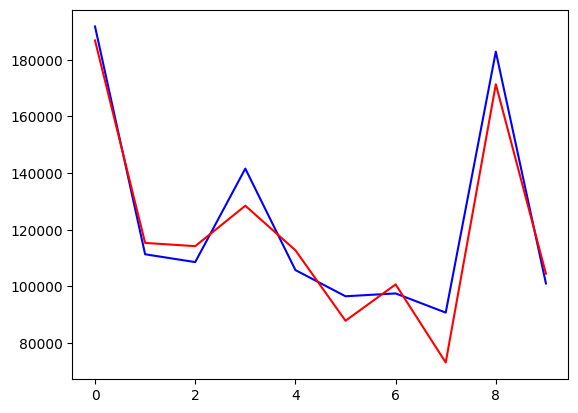

In [23]:
#plotting of y_test and y_pred

plt.plot(y_test, color = 'blue', label = 'test' )
plt.plot(y_pred, color = 'red', label = 'predictions' )
plt.show()

#### Regression Metrics


In [24]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [36]:
mae = mean_absolute_error(y_pred, y_test)
print(mae)

7914.31602912567


In [33]:
mse = mean_squared_error(y_pred, y_test)
print(mse)

83351525.91398099


In [35]:
print(np.sqrt(mse))

9129.70568605478


In [38]:
r2 = r2_score(y_pred, y_test)
print(r2)

0.925159309713263


In [40]:
#Calculate the Adjusted-R-squared

n = X_test.shape[0]
k = X_test.shape[1]

adjusted_r2 = 1-(1-r2)*(n-1)/(n-1-k)
print(adjusted_r2)


0.9158042234274208
